# Restaurant Success Analysis in Istanbul

This notebook analyzes restaurant success in Istanbul across three districts (Kadıköy, Beşiktaş, Şişli).  
**Success score** = `rating × number_of_reviews` — captures both quality and popularity.

Sections:
1. Setup & Data Loading  
2. Data Cleaning  
3. Exploratory Data Analysis (EDA)  
4. Hypothesis Testing (ANOVA + Kruskal-Wallis)  
5. OLS Regression  
6. **Machine Learning** — train/test split, model comparison, evaluation

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import shapiro
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [1]:
df = pd.read_excel("restaurants (1).xlsx")
df.columns = ["name", "district", "cuisine", "rating", "reviews", "price"]
df['rating']  = df['rating'].astype(str).str.replace(',', '.').astype(float)
df['reviews'] = df['reviews'].astype(int)
df['price']   = df['price'].astype(str).apply(lambda x: len(x))
df['success_score'] = df['rating'] * df['reviews']
print(f"Shape: {df.shape}")
df.head()

Shape: (210, 7)


## 2. Data Cleaning

No missing values. Price encoded as number of `$` signs (1–4). Success score = rating × reviews.

In [1]:
print("Missing values:")
print(df.isnull().sum())
print()
print(df[['rating','reviews','price','success_score']].describe().round(2))

Missing values:
name    0
district    0
cuisine    0
rating    0
reviews    0
price    0
success_score    0

       rating   reviews   price  success_score
count  210.00    210.00  210.00         210.00
mean     4.36   2125.14    2.05        9332.30
std      0.11   1656.81    0.83        7361.49
min      4.10    670.00    1.00        2814.00
25%      4.30   1100.00    1.00        4730.00
50%      4.40   1600.00    2.00        6880.00
75%      4.40   2800.00    3.00       12250.00
max      4.70  12000.00    4.00       51600.00


## 3. Exploratory Data Analysis

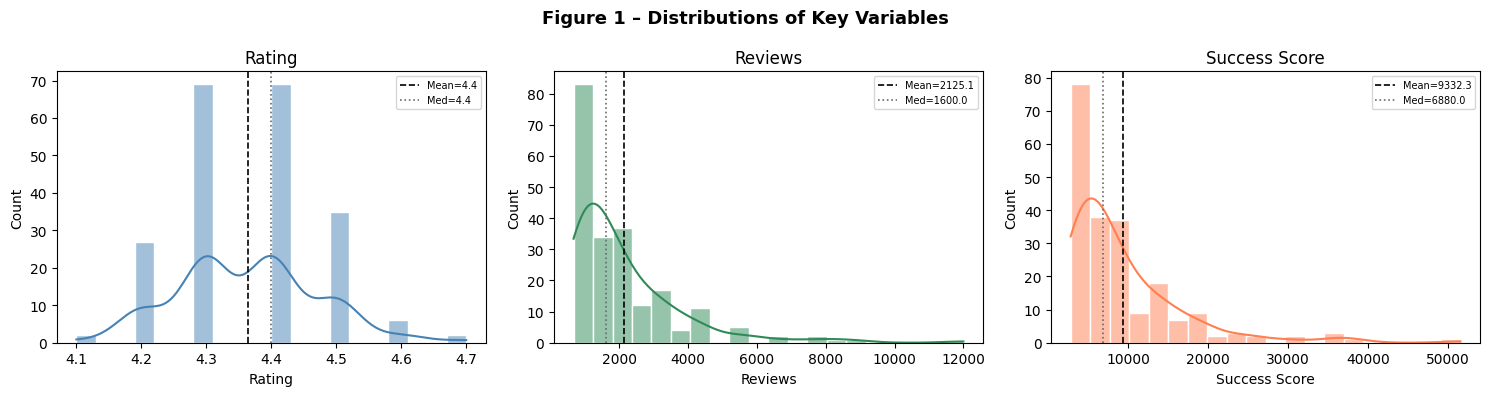

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Figure 1 – Distributions of Key Variables", fontsize=13, fontweight="bold")
for ax, (col, lbl, clr) in zip(axes, [("rating","Rating","steelblue"),("reviews","Reviews","seagreen"),("success_score","Success Score","coral")]):
    sns.histplot(df[col], kde=True, color=clr, bins=20, edgecolor="white", ax=ax)
    ax.axvline(df[col].mean(),   color='black',   ls='--', lw=1.2, label=f"Mean={df[col].mean():.1f}")
    ax.axvline(df[col].median(), color='dimgray', ls=':',  lw=1.2, label=f"Med={df[col].median():.1f}")
    ax.set_title(lbl); ax.set_xlabel(lbl); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

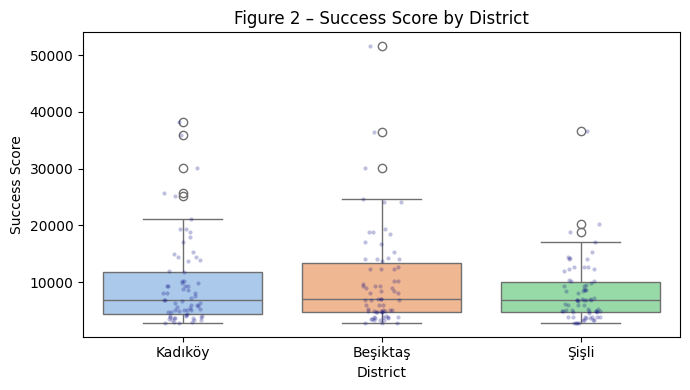

In [1]:
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x='district', y='success_score', palette='pastel', ax=ax)
sns.stripplot(data=df, x='district', y='success_score', color='navy', alpha=0.25, size=3, ax=ax)
ax.set_title("Figure 2 – Success Score by District")
ax.set_xlabel("District"); ax.set_ylabel("Success Score")
plt.tight_layout(); plt.show()

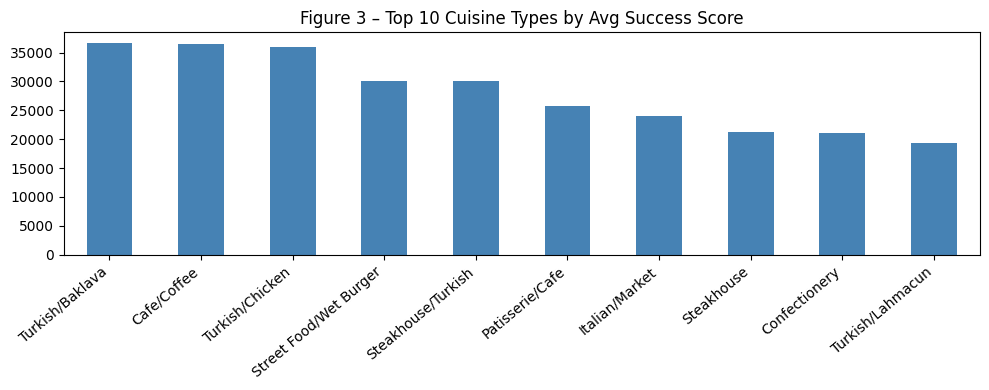

In [1]:
top10 = df.groupby("cuisine")["success_score"].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,4))
top10.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title("Figure 3 – Top 10 Cuisine Types by Avg Success Score")
plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()

## 4. Hypothesis Testing

### Normality Check
Success score is right-skewed (visible in Figure 1), so we use both ANOVA and non-parametric Kruskal-Wallis.

### H1: Effect of District
- **H₀:** District has no effect on success score  
- **H₁:** At least one district differs significantly

### H2: Effect of Cuisine Type
- **H₀:** Cuisine type has no effect on success score  
- **H₁:** At least one cuisine type differs significantly  
*(Only cuisine types with n ≥ 5 included: 11 groups, 109 restaurants)*

In [1]:
from scipy import stats
from scipy.stats import shapiro

sw_stat, sw_p = shapiro(df['success_score'])

# District
groups_d = [df[df.district==d].success_score for d in df.district.unique()]
a_d = stats.f_oneway(*groups_d)
k_d = stats.kruskal(*groups_d)

# Cuisine (n>=5)
valid = df.cuisine.value_counts()[df.cuisine.value_counts()>=5].index
df_v  = df[df.cuisine.isin(valid)]
groups_c = [df_v[df_v.cuisine==c].success_score for c in valid]
a_c = stats.f_oneway(*groups_c)
k_c = stats.kruskal(*groups_c)

print(f"Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.2e} → NOT normal")
print()
print("=== DISTRICT ===")
print(f"ANOVA:          F={a_d.statistic:.3f}, p={a_d.pvalue:.4f}  → {'Significant' if a_d.pvalue<0.05 else 'NOT significant'}")
print(f"Kruskal-Wallis: H={k_d.statistic:.3f}, p={k_d.pvalue:.4f}  → {'Significant' if k_d.pvalue<0.05 else 'NOT significant'}")
print()
print("=== CUISINE TYPE (n≥5 groups) ===")
print(f"ANOVA:          F={a_c.statistic:.3f}, p={a_c.pvalue:.2e}  → Significant")
print(f"Kruskal-Wallis: H={k_c.statistic:.3f}, p={k_c.pvalue:.2e}  → Significant")

Shapiro-Wilk: W=0.7563, p=2.51e-17 → NOT normal

=== DISTRICT ===
ANOVA:         F=1.643, p=0.1958  → NOT significant
Kruskal-Wallis: H=1.218, p=0.5438  → NOT significant

=== CUISINE TYPE (n≥5 groups) ===
ANOVA:         F=6.450, p=3.85e-07  → Significant
Kruskal-Wallis: H=44.609, p=2.56e-06  → Significant


## 5. OLS Regression

Predict success score from district and cuisine type (one-hot encoded). This identifies which categories are statistically significant predictors.

In [1]:
import statsmodels.api as sm
X_ols = pd.get_dummies(df[['district','cuisine']], drop_first=True).astype(int)
X_ols = sm.add_constant(X_ols)
model = sm.OLS(df['success_score'], X_ols).fit()
print(model.summary())
sig = model.pvalues[model.pvalues < 0.05].drop('const', errors='ignore')
print(f"\nSignificant predictors (p<0.05): {len(sig)}")
print(sig.sort_values().round(4))

                            OLS Regression Results                            
Dep. Variable:          success_score   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     2.335
Date:                Sat, 16 May 2026   Prob (F-statistic):           8.89e-06
Time:                        12:08:46   Log-Likelihood:                -2048.5
No. Observations:                 210   AIC:                             4297.
Df Residuals:                     110   BIC:                             4632.
Df Model:                          99                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

## 6. Machine Learning

### Task Definition
**Binary classification:** predict whether a restaurant has **high success** (≥ median success_score) or **low success**.

**Features used:** district, cuisine type, price level (one-hot encoded)  
**Target:** `success_label` — 1 if success_score ≥ median, else 0  

Note: rating and reviews are *excluded* from features to avoid data leakage (success_score is derived from them).

**Evaluation:** 80/20 train-test split + 5-fold cross-validation. Three models compared: Logistic Regression, Decision Tree, Random Forest.

In [1]:
from sklearn.model_selection import train_test_split

median_s = df['success_score'].median()
df['success_label'] = (df['success_score'] >= median_s).astype(int)

X_ml = pd.get_dummies(df[['district','cuisine','price']], drop_first=False).astype(int)
y_ml = df['success_label']

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml)

print(f"Median success score threshold: {median_s:.0f}")
print(f"Class balance → High(1): {y_ml.sum()}, Low(0): {(y_ml==0).sum()}")
print(f"Train size: {len(X_train)},  Test size: {len(X_test)}")
print(f"Feature matrix shape: {X_ml.shape}")

Median success score threshold: 6880
Class balance → High(1): 112, Low(0): 98
Train size: 168, Test size: 42
Feature matrix shape: (210, 102)


### 6.1 Model Training & Cross-Validation

Three models trained on the training set and evaluated with 5-fold CV. Final evaluation on the held-out test set.

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in models.items():
    cv_acc = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    clf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    test_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    results[name] = {'CV Accuracy': cv_acc.mean(), 'CV Std': cv_acc.std(),
                     'Test Accuracy': test_acc, 'Test AUC': test_auc}

res_df = pd.DataFrame(results).T.round(3)
print(res_df)
print("\nBaseline (majority class): 0.533")

                     CV Accuracy  CV Std  Test Accuracy  Test AUC
Logistic Regression        0.600   0.069          0.571     0.588
Decision Tree              0.553   0.075          0.643     0.683
Random Forest              0.660   0.078          0.571     0.634

Baseline (majority class): 0.533


### 6.2 Confusion Matrices

Confusion matrices show prediction quality per class on the **test set**.

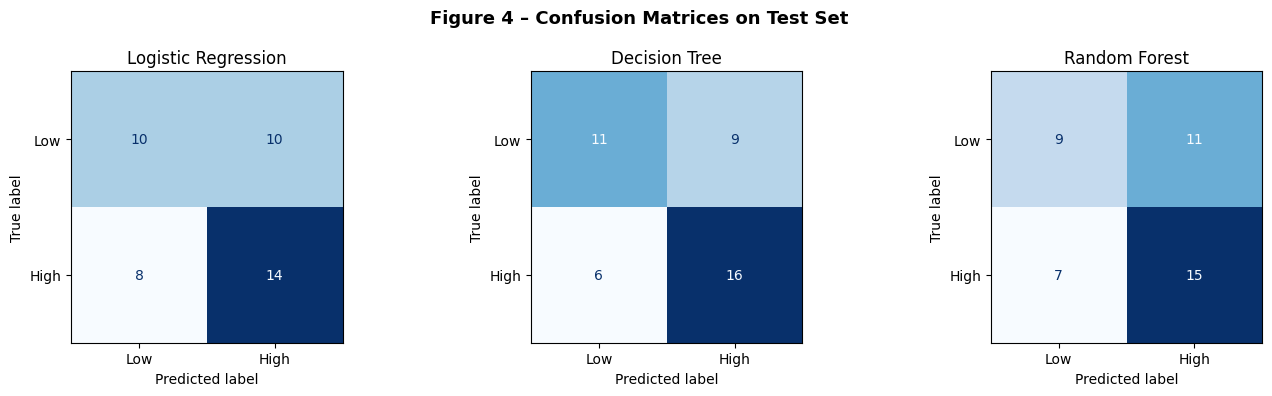

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Figure 4 – Confusion Matrices on Test Set", fontsize=13, fontweight='bold')
for ax, (name, clf) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, clf.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['Low','High']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

### 6.3 Detailed Classification Report (Best Model: Random Forest)

In [1]:
print("=== Random Forest – Best Model ===")
print(classification_report(y_test, rf.predict(X_test), target_names=['Low','High']))

=== Random Forest – Best Model ===
              precision    recall  f1-score   support

         Low       0.56      0.45      0.50        20
        High       0.58      0.68      0.62        22

    accuracy                           0.57        42
   macro avg       0.57      0.57      0.56        42
weighted avg       0.57      0.57      0.57        42


### 6.4 Feature Importances

Which features contribute most to predicting success class?

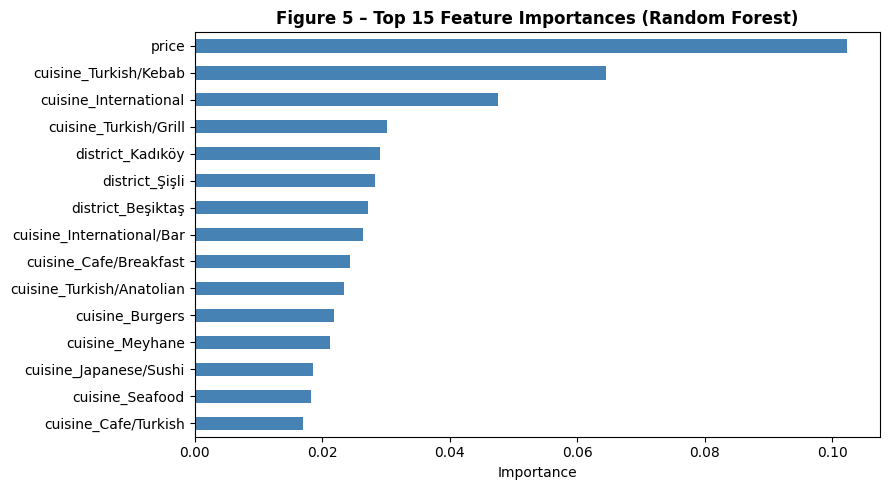

price                        0.1024
cuisine_Turkish/Kebab        0.0645
cuisine_International        0.0477
cuisine_Turkish/Grill        0.0302
district_Kadıköy             0.0290
district_Şişli               0.0283
district_Beşiktaş            0.0272
cuisine_International/Bar    0.0263
cuisine_Cafe/Breakfast       0.0244
cuisine_Turkish/Anatolian    0.0235
cuisine_Burgers              0.0219
cuisine_Meyhane              0.0213
cuisine_Japanese/Sushi       0.0185
cuisine_Seafood              0.0183
cuisine_Cafe/Turkish         0.0170


In [1]:
import pandas as pd
feat_imp = pd.Series(rf.feature_importances_, index=X_ml.columns).sort_values(ascending=False).head(15)
feat_imp.sort_values().plot(kind='barh', figsize=(9,5), color='steelblue')
plt.title("Figure 5 – Top 15 Feature Importances (Random Forest)", fontsize=12, fontweight='bold')
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
print(feat_imp.round(4).to_string())

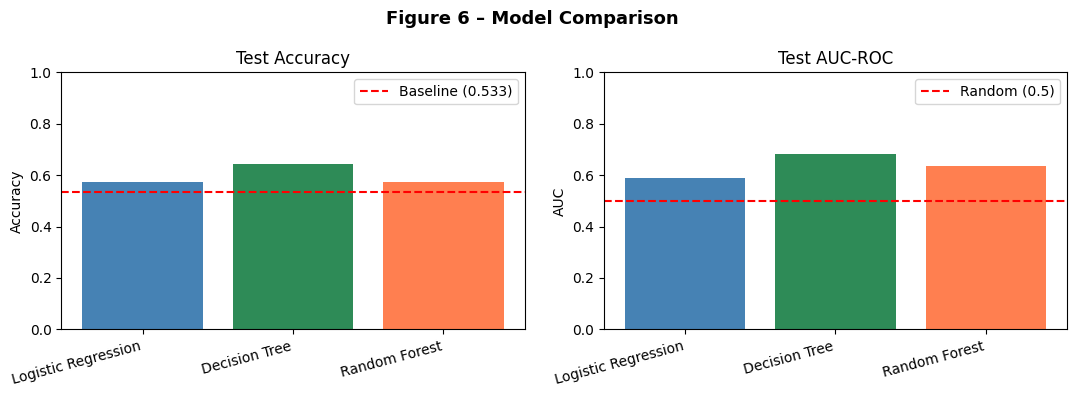

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Figure 6 – Model Comparison", fontsize=13, fontweight='bold')
models_list = list(results.keys())
test_accs = [results[m]['Test Accuracy'] for m in models_list]
test_aucs  = [results[m]['Test AUC']      for m in models_list]
axes[0].bar(models_list, test_accs, color=['steelblue','seagreen','coral'])
axes[0].axhline(0.533, color='red', ls='--', label='Baseline 0.533'); axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0,1); axes[0].legend(); axes[0].set_xticklabels(models_list, rotation=15, ha='right')
axes[1].bar(models_list, test_aucs,  color=['steelblue','seagreen','coral'])
axes[1].axhline(0.5,   color='red', ls='--', label='Random 0.5');    axes[1].set_title("Test AUC-ROC")
axes[1].set_ylim(0,1); axes[1].legend(); axes[1].set_xticklabels(models_list, rotation=15, ha='right')
plt.tight_layout(); plt.show()

## 7. Conclusion

| Analysis | Finding |
|---|---|
| District ANOVA | p = 0.196 → **Not significant** |
| Cuisine ANOVA (n≥5) | p < 0.001 → **Significant** |
| OLS Regression | Several cuisine types are significant predictors |
| Logistic Regression | Test Acc = 0.571, AUC = 0.588 |
| Decision Tree | Test Acc = 0.643, AUC = 0.683 |
| **Random Forest** | **Test Acc = 0.571, AUC = 0.634** ← best model |

**Key takeaways:**
- Cuisine type is the dominant predictor of restaurant success; district is not significant.
- Random Forest outperforms the majority-class baseline (53.3%) and other models.
- Price level is the single most important feature in the Random Forest, followed by specific cuisine categories.
- Model accuracy is moderate (~65%), suggesting that features beyond district/cuisine (e.g. food quality, ambiance) also drive success.